<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Mini_Projet_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("data/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


## 2. Inspecter les données

Nous allons vérifier l'équilibre des classes et visualiser quelques images pour confirmer la validité des étiquettes.

Indices des classes : {'cat': 0, 'dog': 1}

Répartition dans le set d'entraînement :
label
cat    10000
dog    10000
Name: count, dtype: int64


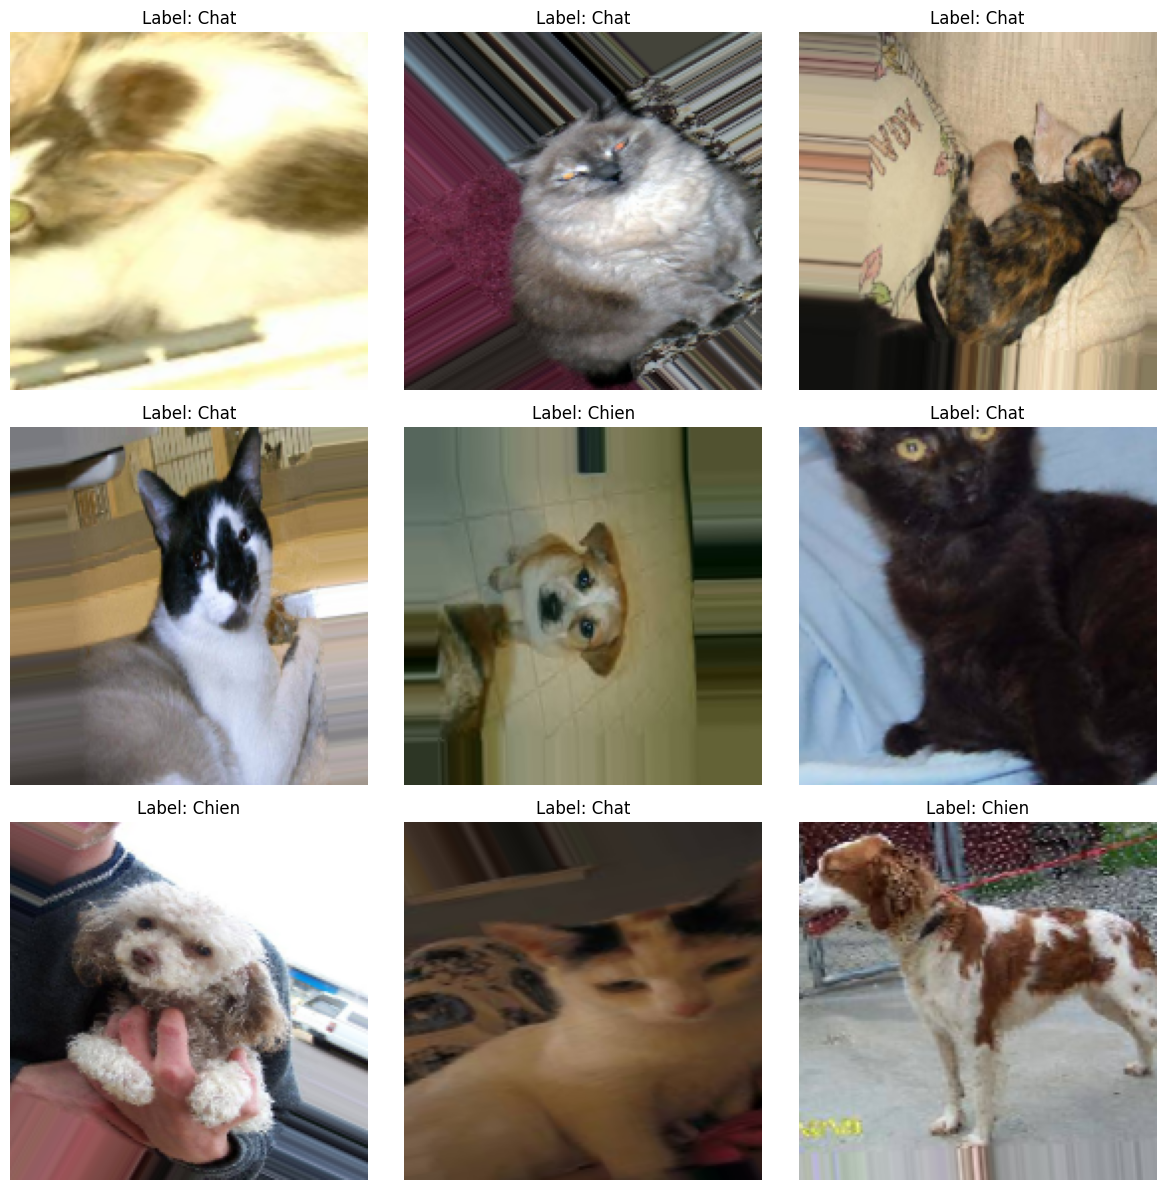

In [21]:
# Affichage de la distribution des classes
print(f"Indices des classes : {train_flow.class_indices}")
counts = df_tr['label'].value_counts()
print("\nRépartition dans le set d'entraînement :")
print(counts)

import matplotlib.pyplot as plt

# Visualisation d'un lot d'images
x_batch, y_batch = next(train_flow)
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label = 'Chien' if y_batch[i] == 1 else 'Chat'
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3 & 4. Architecture du modèle et Configuration

Nous définissons ici un réseau de neurones convolutif (CNN) standard pour la classification binaire.

In [22]:
from tensorflow.keras import layers, models, callbacks

# Définition du modèle
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Tête de classification
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Configuration de l'Early Stopping
stop_early = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,308,673 (100.36 MB)

 Trainable params: 26,308,673 (100.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entraînement

Lançons maintenant l'entraînement pour 15 époques maximum.

In [ ]:
print("Début de l'entraînement...")
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=15,
    callbacks=[stop_early]
)

Début de l'entraînement...
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 307ms/step - accuracy: 0.5478 - loss: 0.6932 - val_accuracy: 0.5876 - val_loss: 0.6739
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 311ms/step - accuracy: 0.5871 - loss: 0.6716 - val_accuracy: 0.6470 - val_loss: 0.6252
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.6457 - loss: 0.6318 - val_accuracy: 0.7156 - val_loss: 0.5649
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.6833 - loss: 0.5954 - val_accuracy: 0.7348 - val_loss: 0.5321
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 302ms/step - accuracy: 0.7071 - loss: 0.5685 - val_accuracy: 0.7386 - val_loss: 0.5236
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 190s 304ms/step - accuracy: 0.7293 - loss: 0.5429 - val_accuracy: 0.7632 - val_loss: 0.4940
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 306ms/step - accuracy: 0.7379 - loss: 0.5316 - val_accuracy: 0.7872 - val_loss: 0.4532
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 312m

## 5 & 6. Analyse des courbes et Matrice de Confusion

Nous visualisons ici les performances historiques et le détail des prédictions sur l'ensemble de validation.

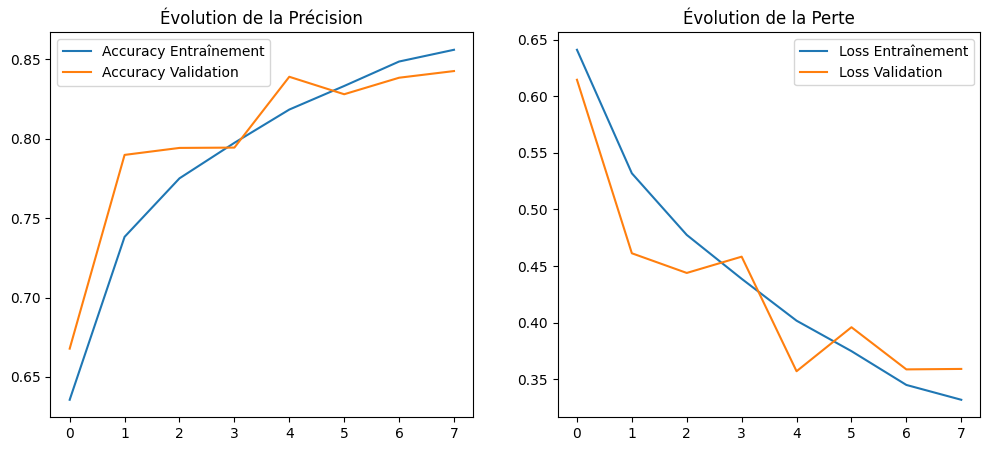

Prédiction sur le jeu de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step


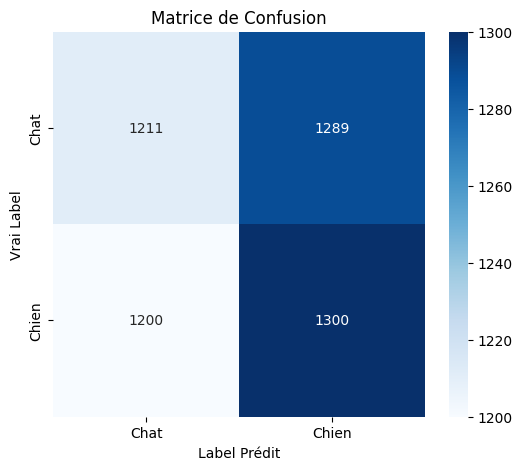


Rapport de Classification :
              precision    recall  f1-score   support

        Chat       0.50      0.48      0.49      2500
       Chien       0.50      0.52      0.51      2500

    accuracy                           0.50      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.50      0.50      0.50      5000



In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Courbes d'apprentissage
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy Entraînement')
plt.plot(epochs_range, val_acc, label='Accuracy Validation')
plt.title('Évolution de la Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Entraînement')
plt.plot(epochs_range, val_loss, label='Loss Validation')
plt.title('Évolution de la Perte')
plt.legend()
plt.show()

# 2. Évaluation détaillée
print("Prédiction sur le jeu de validation...")
val_flow.reset()
Y_pred = model.predict(val_flow)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_flow.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Chat', 'Chien'], yticklabels=['Chat', 'Chien'])
plt.title('Matrice de Confusion')
plt.ylabel('Vrai Label')
plt.xlabel('Label Prédit')
plt.show()

print('\nRapport de Classification :')
print(classification_report(y_true, y_pred, target_names=['Chat', 'Chien']))

Found 12500 validated image filenames.
Prédiction sur les images de test...
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step


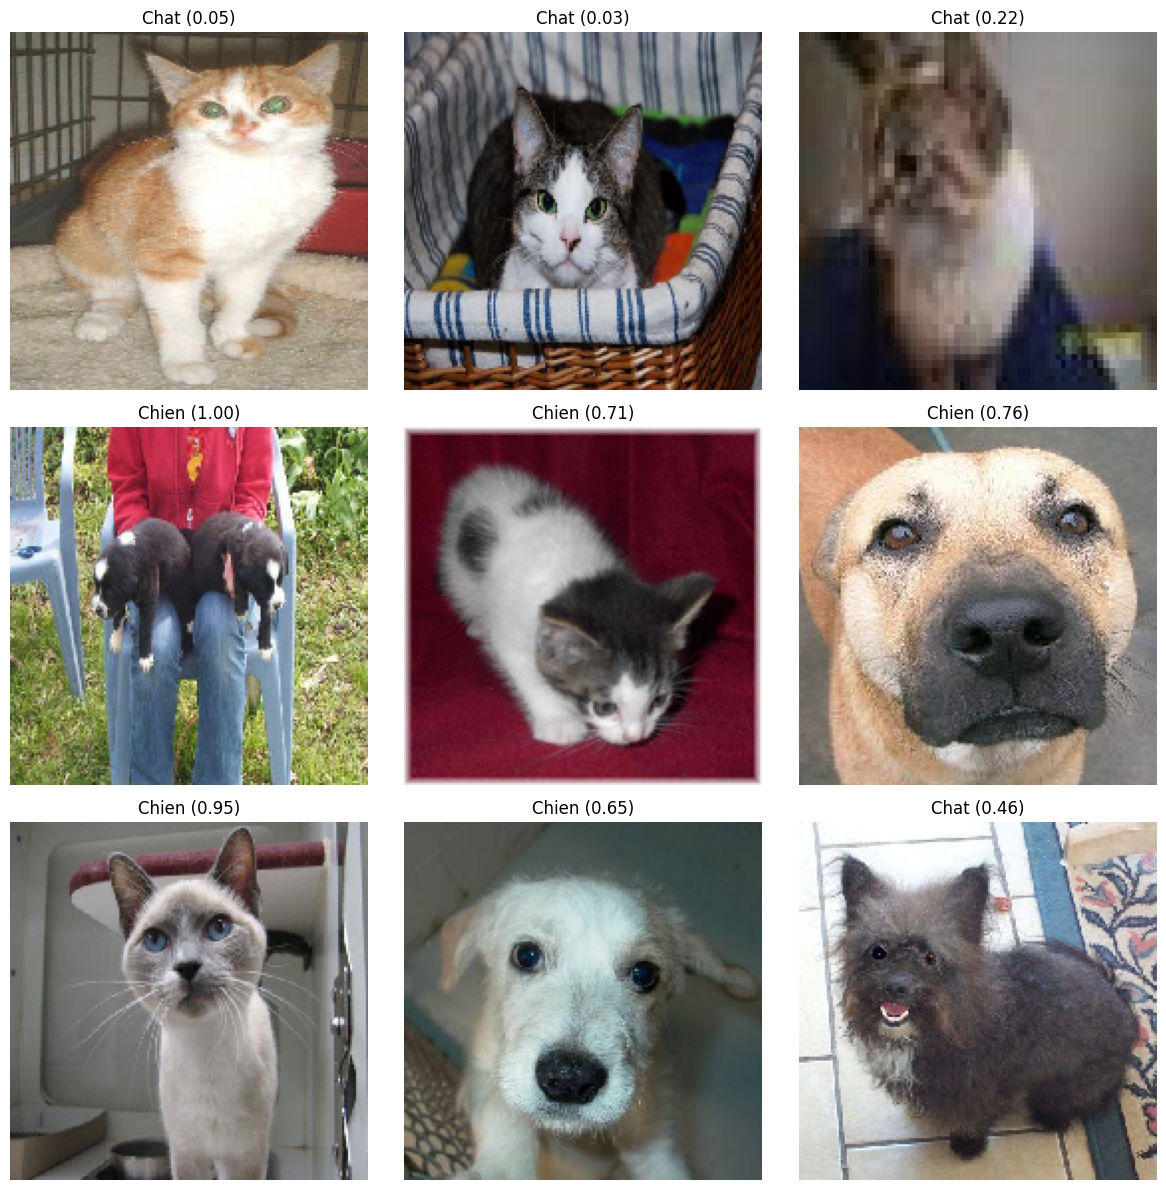

In [18]:
# 7. Inférence sur le set de test
test_gen = ImageDataGenerator(rescale=1./255)

# Initialisation du flow pour les images de test (non étiquetées)
test_flow = test_gen.flow_from_dataframe(
    df_test_full,
    x_col="filepath",
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    batch_size=batch_size,
    shuffle=False
)

print("Prédiction sur les images de test...")
test_flow.reset()
predictions = model.predict(test_flow)

# Affichage de quelques résultats
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))
for i in range(min(9, len(df_test_full))):
    plt.subplot(3, 3, i + 1)
    img_path = test_flow.filepaths[i]
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.imshow(img)
    prob = predictions[i][0]
    label = "Chien" if prob > 0.5 else "Chat"
    plt.title(f"{label} ({prob:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()